# Análisis de Similitud Curricular — Nivel 2: Embeddings Semánticos Directos

**Proyecto:** TIC-D — Análisis de similitud curricular entre carreras de la EPN y universidades OCDE  
**Autor:** Glenn  
**Institución:** Escuela Politécnica Nacional (EPN)

---

## ¿Qué es el Nivel 2 y en qué se diferencia de los otros niveles?

Este notebook implementa el **Nivel 2** de la metodología de análisis curricular. Para entender qué hace, es útil ver cómo se diferencia de los otros niveles:

| Nivel | Nombre | Qué representa cada carrera | Interpretable |
|---|---|---|---|
| 1 | TF-IDF | Vector de frecuencias de palabras | Sí — cada posición es una palabra |
| **2** | **Embeddings directos** | **Vector semántico de 1024 dimensiones** | **No — caja negra semántica** |
| 3 | Vectores ESCO | Vector de 4241 scores de habilidades | Sí — cada posición es una habilidad ESCO |

### La diferencia clave con el Nivel 3

En el **Nivel 3**, los embeddings se usaban como herramienta intermedia:
```
Texto → Embedding → Comparar contra ESCO → Vector ESCO → Similitud entre carreras
```

En el **Nivel 2**, los embeddings son la representación final:
```
Texto → Embedding → Similitud directa entre carreras
```

No hay intermediario. El modelo compara el **significado global** de los perfiles directamente.

### ¿Por qué es importante tener este nivel?

Completa la cadena comparativa de la tesis. Sin él, el salto de TF-IDF a ESCO es brusco. Con los tres niveles se puede argumentar:

> *"Comenzamos con un baseline léxico (TF-IDF), avanzamos a una representación semántica directa (Nivel 2), y finalmente a una representación basada en competencias estandarizadas (ESCO). Cada nivel agrega una capa de interpretabilidad y profundidad semántica al análisis."*

---

## Modelos evaluados

| Modelo | Organización | Dimensión | Límite de tokens | Característica principal |
|---|---|---|---|---|
| `BAAI/bge-m3` | BAAI | 1024 | **8192** | Soporta textos muy largos, multilingüe |
| `intfloat/multilingual-e5-large` | Microsoft | 1024 | **512** | Optimizado para similitud semántica |

**Nota sobre E5 y el límite de tokens:**  
Los perfiles del dataset tienen en promedio ~228 tokens y un máximo de ~1352 tokens. BGE-M3 los procesa todos íntegramente. E5 trunca los textos que superen 512 tokens — esto es una limitación documentada que afecta a un subconjunto de carreras con perfiles muy extensos.

---

## Pipeline del Nivel 2

```
PASO 1: Texto de carrera
        perfil_egreso + perfil_profesional
        ↓
PASO 2: Embedding semántico directo
        texto → vector de 1024 dimensiones
        (el modelo convierte el significado en números)
        ↓
PASO 3: Similitud coseno entre embeddings
        emb[i] · emb[j] / (||emb[i]|| × ||emb[j]||)
        → matriz 163 × 163
        ↓
PASO 4: Clustering jerárquico + visualizaciones
        dendrograma, heatmap, métricas
```

---

## Estructura del notebook

| Sección | Contenido | Prerequisito |
|---|---|---|
| 0 | Configuración e imports | Siempre |
| 1 | Carga de datos y generación de embeddings | Sección 0 |
| 2 | Dendrograma de similitud semántica | Sección 1 |
| 3 | Heatmap de similitud entre carreras | Sección 1 |
| 4 | Métricas de evaluación | Sección 1 |
| 5 | Comparación BGE-M3 vs E5 | Sección 4 |
| 6 | Comparación Nivel 1 vs Nivel 2 vs Nivel 3 | Secciones 4 y 5 |
| 7 | Interpretación y conclusiones | Secciones 4, 5 y 6 |

---
## Sección 0 — Configuración e Imports

**Qué hace esta celda:**  
Importa todas las librerías necesarias y define las rutas del proyecto.

**Librerías y su función específica en este notebook:**

| Librería | Función |
|---|---|
| `sentence_transformers` | Carga los modelos BGE-M3 y E5, genera los embeddings |
| `torch` | Backend de PyTorch para cómputo en GPU (CUDA) |
| `numpy` | Operaciones matriciales sobre los embeddings |
| `sklearn.metrics.pairwise` | `cosine_similarity` — calcula similitud entre todos los pares de embeddings |
| `scipy.cluster.hierarchy` | Clustering jerárquico y generación del dendrograma |
| `matplotlib` | Visualizaciones: dendrograma, heatmap, tabla de métricas |

**Cuándo ejecutar:** Siempre primero. Si reinicias Jupyter, vuelve a ejecutar esta celda.

In [7]:
import glob
import json
import time
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import (
    dendrogram, linkage, cophenet,
    fcluster, leaves_list
)
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# ── Verificar disponibilidad de GPU ───────────────────────────────────────────
# Los embeddings se calculan en GPU si está disponible (mucho más rápido).
# Si no hay GPU, se usa CPU (más lento pero funciona igual).
try:
    import torch
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    if DEVICE == 'cuda':
        GPU_NAME = torch.cuda.get_device_name(0)
    else:
        GPU_NAME = 'No disponible'
except ImportError:
    DEVICE   = 'cpu'
    GPU_NAME = 'PyTorch no instalado'

# ── Rutas del proyecto ────────────────────────────────────────────────────────
BASE_DIR = Path(__file__).parent.parent if '__file__' in dir() else Path('..')   # raíz de TIC-D
PROCESSED  = BASE_DIR / 'data' / 'processed'
OUTPUT_DIR = BASE_DIR / "outputs" / date.today().isoformat() / "nivel2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Paleta de colores por universidad ─────────────────────────────────────────
PALETA = {
    'EPN':'#1a56db','ESPOL':'#0e9f6e','UPS':'#e3a008','ESPOCH':'#9061f9',
    'UCE':'#e02424','UTM':'#ff5a1f','UG':'#057a55','USFQ':'#0694a2',
    'UDLA':'#c81e1e','UTPL':'#5521b5','ESPE':'#1e429f','UCSG':'#723b13',
    'PUCE':'#014737','UTN':'#6b21a8',
}
def get_color(sig):
    return PALETA.get(sig, '#4b5563')

print('✓ Configuración completada')
print(f'  Dispositivo de cómputo: {DEVICE.upper()}')
if DEVICE == 'cuda':
    print(f'  GPU detectada:          {GPU_NAME}')
    print(f'  Los embeddings se generarán en GPU (rápido)')
else:
    print(f'  Los embeddings se generarán en CPU (más lento, ~20-40 min)')
print(f'  Directorio base:        {BASE_DIR.resolve()}')
print(f'  Salida de hoy:          {OUTPUT_DIR.resolve()}')

✓ Configuración completada
  Dispositivo de cómputo: CUDA
  GPU detectada:          NVIDIA GeForce RTX 3050
  Los embeddings se generarán en GPU (rápido)
  Directorio base:        D:\Repositories\TIC-D
  Salida de hoy:          D:\Repositories\TIC-D\outputs\2026-07-03\nivel2


---
## Sección 1 — Carga de Datos y Generación de Embeddings

**Qué hace esta celda:**  
Carga el dataset de carreras, carga el modelo de embeddings seleccionado y genera un vector de 1024 dimensiones para cada carrera.

### ¿Qué es un embedding?

Un embedding es la transformación de un texto en un vector numérico que captura su **significado semántico**. Dos textos con significado similar producen vectores que apuntan en direcciones parecidas en el espacio de 1024 dimensiones, aunque usen palabras completamente distintas.

Por ejemplo:
- *"diseña e implementa sistemas de software"* → vector A
- *"desarrolla y construye soluciones informáticas"* → vector B
- **similitud coseno(A, B) ≈ 0.94** ← muy similares aunque no comparten palabras

### ¿Cómo funciona `normalize_embeddings=True`?

Al normalizar, cada vector queda con longitud (norma L2) igual a 1. Esto hace que el **producto punto** entre dos vectores sea equivalente a la **similitud coseno**, lo que simplifica el cálculo posterior:

```
similitud_coseno(A, B) = (A · B) / (||A|| × ||B||)
                       = A · B  ← si ||A|| = ||B|| = 1
```

### Sobre el prefijo `query:` en E5

El modelo E5 fue entrenado con un formato especial: los textos a recuperar llevan el prefijo `"passage: "` y las consultas llevan `"query: "`. Para uso simétrico (comparar documentos entre sí, no buscar), se usa `"query: "` en ambos lados. Esto es un detalle de implementación del modelo que no afecta el resultado conceptual.

### Tiempo estimado de ejecución
- **Con GPU (RTX 3050):** ~2-4 minutos por modelo
- **Con CPU:** ~20-40 minutos por modelo

**Parámetro configurable:** `MODELO` — cambia entre los dos modelos disponibles

In [12]:
# ── PARÁMETRO CONFIGURABLE ────────────────────────────────────────────────────
# MODELO = 'BAAI/bge-m3'
MODELO = 'intfloat/multilingual-e5-large'
# Opciones:
#   'BAAI/bge-m3'                      → hasta 8192 tokens, multilingüe
#   'intfloat/multilingual-e5-large'   → hasta 512 tokens, textos largos se truncan

METODO     = 'ward'   # Método de linkage para clustering jerárquico
BATCH_SIZE = 64       # Carreras procesadas por lote en GPU
                      # Reducir a 32 si hay error de memoria en GPU
# ─────────────────────────────────────────────────────────────────────────────

# Nombre corto para usar en nombres de archivos
MODELO_SHORT = MODELO.split('/')[-1]

# --- Cargar dataset de carreras ---
df_carreras = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'carreras_homologas.csv')
df_carreras['perfil_egreso']      = df_carreras['perfil_egreso'].fillna('')
df_carreras['perfil_profesional'] = df_carreras['perfil_profesional'].fillna('')

# Construir el corpus de texto: concatenar perfil_egreso + perfil_profesional
# Estos dos campos son los que mejor describen qué sabe hacer un graduado
# y en qué puede trabajar — lo que queremos comparar entre carreras
if 'e5' in MODELO.lower():
    # E5 requiere el prefijo 'query:' para búsqueda simétrica entre documentos
    corpus = [
        f"query: {row['perfil_egreso']} {row['perfil_profesional']}"
        for _, row in df_carreras.iterrows()
    ]
    print('⚠ Modelo E5: se agrega prefijo "query:" a cada texto')
    print(f'  Textos con más de 512 tokens serán truncados')
    n_truncados = sum(
        1 for _, r in df_carreras.iterrows()
        if len((r['perfil_egreso'] + r['perfil_profesional']).split()) > 380
    )
    print(f'  Carreras posiblemente afectadas por truncamiento: ~{n_truncados}')
else:
    corpus = [
        f"{row['perfil_egreso']} {row['perfil_profesional']}"
        for _, row in df_carreras.iterrows()
    ]

print(f'\nDataset cargado:')
print(f'  Carreras:       {len(df_carreras)}')
print(f'  Universidades:  {df_carreras["siglas"].nunique()}')
print(f'  Longitud media de texto: {np.mean([len(t) for t in corpus]):.0f} chars')
print(f'  Longitud máxima:         {max([len(t) for t in corpus])} chars')

# --- Cargar modelo de embeddings ---
print(f'\nCargando modelo: {MODELO}')
print(f'(Primera vez: descarga ~2GB, las siguientes usa caché local)')

from sentence_transformers import SentenceTransformer
t0    = time.time()
model = SentenceTransformer(MODELO, device=DEVICE)
print(f'✓ Modelo cargado en {time.time()-t0:.1f}s')

# --- Generar embeddings ---
# model.encode() procesa el corpus en lotes de BATCH_SIZE textos
# normalize_embeddings=True → cada vector queda con norma L2 = 1
#   esto permite usar producto punto en lugar de similitud coseno completa
# convert_to_numpy=True → retorna ndarray en lugar de tensor PyTorch
# show_progress_bar=True → muestra progreso mientras procesa los lotes
print(f'\nGenerando embeddings para {len(corpus)} carreras...')
t0 = time.time()
embeddings = model.encode(
    corpus,
    batch_size=BATCH_SIZE,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=True,
)
t_embed = time.time() - t0
print(f'✓ Embeddings generados en {t_embed:.1f}s')
print(f'  Shape: {embeddings.shape}  → {embeddings.shape[0]} carreras × {embeddings.shape[1]} dimensiones')

# --- Calcular similitud coseno entre todos los pares de carreras ---
# Como los embeddings están normalizados (norma = 1),
# cosine_similarity equivale al producto punto: sim[i,j] = emb[i] · emb[j]
# El resultado es una matriz 163×163 donde sim[i,j] ∈ [-1, 1]
# Para embeddings semánticos, valores negativos son muy raros — típicamente [0, 1]
print(f'\nCalculando similitud coseno entre los {len(df_carreras)} embeddings...')
sim_cc = cosine_similarity(embeddings)  # (163, 163)
np.fill_diagonal(sim_cc, 1.0)           # diagonal = 1 por definición

# Convertir a distancia para el clustering
# dist[i,j] = 1 - sim[i,j]
# → 0.0 = idénticas, 1.0 = completamente opuestas
dist_cc = np.clip(1 - sim_cc, 0, None)
np.fill_diagonal(dist_cc, 0)

# --- Guardar embeddings para uso posterior ---
emb_path = PROCESSED / f'embeddings_nivel2_{MODELO_SHORT}_{date.today().isoformat()}.npy'
np.save(emb_path, embeddings)

# --- Resumen ---
mask      = ~np.eye(sim_cc.shape[0], dtype=bool)
sim_vals  = sim_cc[mask]
print(f'\n✓ Resumen:')
print(f'  Modelo:          {MODELO}')
print(f'  Embeddings:      {embeddings.shape}')
print(f'  Tiempo total:    {t_embed:.1f}s')
print(f'  Similitud mín:   {sim_vals.min():.4f}  (par más distinto)')
print(f'  Similitud máx:   {sim_vals.max():.4f}  (par más similar sin ser la misma)')
print(f'  Similitud media: {sim_vals.mean():.4f}')
print(f'  Embeddings guardados en: {emb_path}')

⚠ Modelo E5: se agrega prefijo "query:" a cada texto
  Textos con más de 512 tokens serán truncados
  Carreras posiblemente afectadas por truncamiento: ~16

Dataset cargado:
  Carreras:       163
  Universidades:  14
  Longitud media de texto: 917 chars
  Longitud máxima:         5417 chars

Cargando modelo: intfloat/multilingual-e5-large
(Primera vez: descarga ~2GB, las siguientes usa caché local)
✓ Modelo cargado en 8.4s

Generando embeddings para 163 carreras...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

✓ Embeddings generados en 623.7s
  Shape: (163, 1024)  → 163 carreras × 1024 dimensiones

Calculando similitud coseno entre los 163 embeddings...

✓ Resumen:
  Modelo:          intfloat/multilingual-e5-large
  Embeddings:      (163, 1024)
  Tiempo total:    623.7s
  Similitud mín:   0.8370  (par más distinto)
  Similitud máx:   0.9974  (par más similar sin ser la misma)
  Similitud media: 0.9007
  Embeddings guardados en: ..\data\processed\embeddings_nivel2_multilingual-e5-large_2026-07-03.npy


---
## Sección 2 — Dendrograma de Similitud Semántica

**Qué hace esta celda:**  
Construye y visualiza el árbol jerárquico de similitud entre las 163 carreras basado en sus embeddings semánticos directos.

### ¿Cómo se construye el dendrograma?

El proceso tiene dos pasos:

**1. Clustering jerárquico aglomerativo (método Ward):**  
Empieza con 163 clusters (cada carrera es su propio grupo). En cada iteración fusiona los dos clusters cuya unión minimice el incremento de varianza interna. Continúa hasta que todas las carreras estén en un solo grupo. El resultado es la matriz `Z` que codifica cada fusión: qué dos grupos se unieron y a qué altura (distancia).

**2. Visualización del árbol:**  
La función `dendrogram()` dibuja `Z` como un árbol horizontal. Cada hoja es una carrera. Las ramas que se unen a la izquierda (cerca del eje Y) representan carreras muy similares. Las que se unen lejos a la derecha son carreras muy distintas.

### Cómo interpretar el resultado

- **Eje X = distancia coseno** (1 − similitud). Cuanto más a la derecha se fusionan dos ramas, más diferentes son esas carreras
- **El color de las etiquetas** identifica la universidad de cada carrera
- **La línea de corte vertical** (umbral automático al 60% de la altura máxima) indica dónde el algoritmo distingue clusters naturales
- **Un agrupamiento coherente** significa que las carreras del mismo nombre (ej. todas las Ingenierías Civiles) forman una rama antes de unirse con carreras de otras áreas

Árbol de clustering construido:
  Método: ward
  Altura máxima de fusión: 0.5983
  Umbral de corte visual:  0.3590 (60% de la altura máxima)


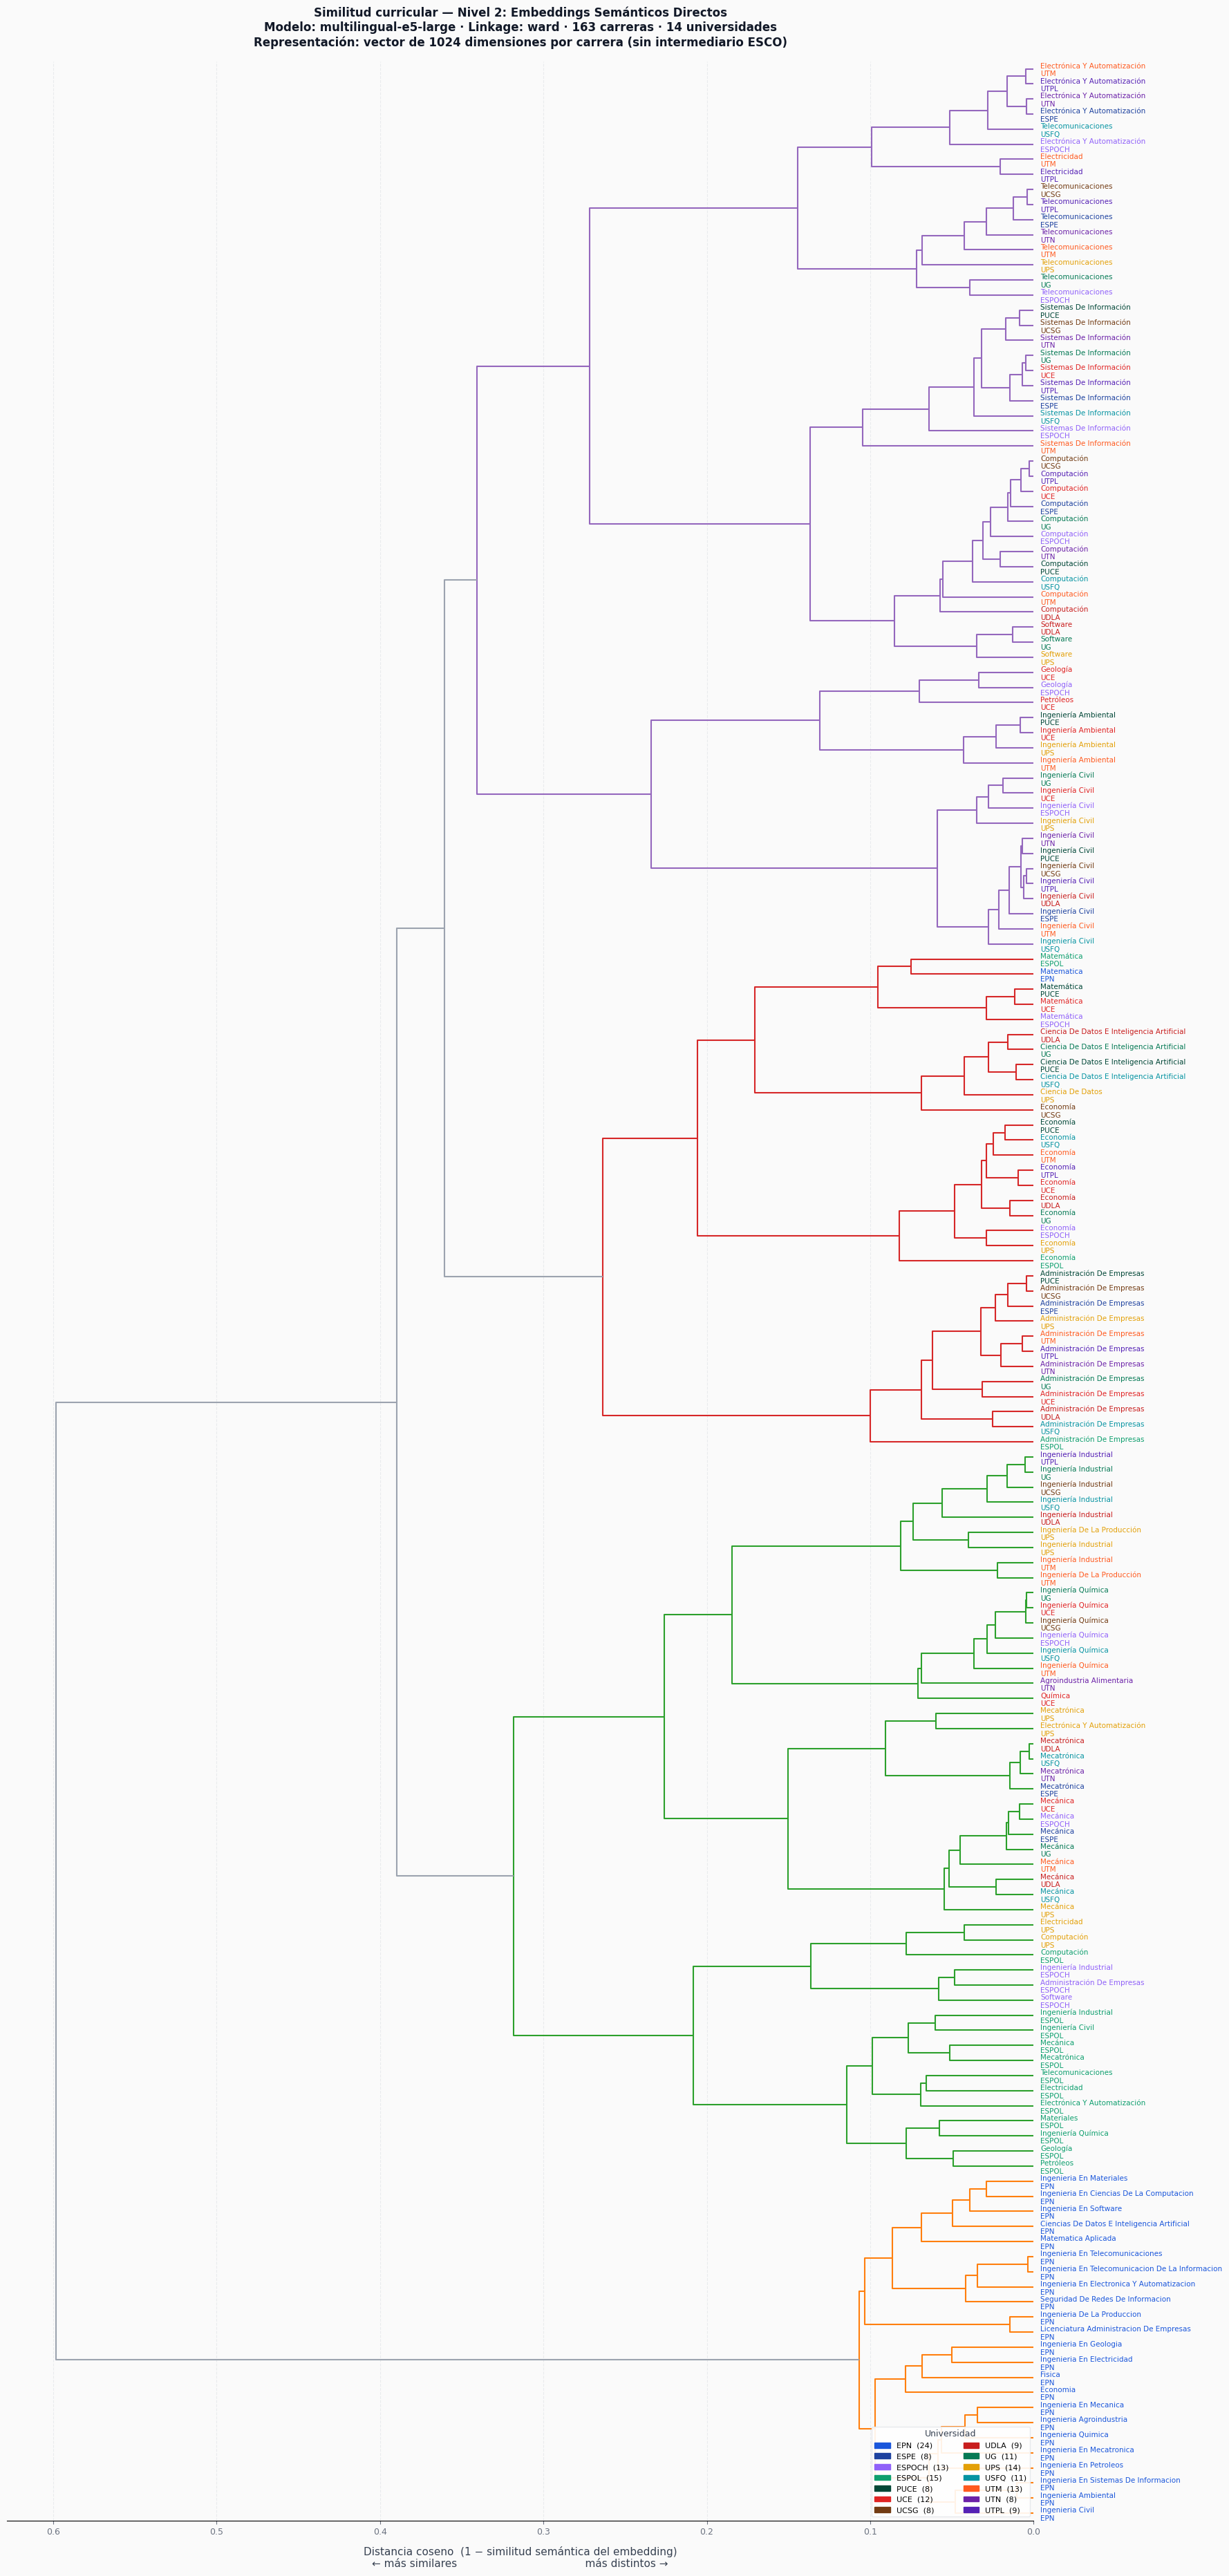


✓ PNG guardado: ..\outputs\2026-07-03\nivel2\dendrograma_nivel2_multilingual-e5-large_2026-07-03.png
✓ PDF guardado: ..\outputs\2026-07-03\nivel2\dendrograma_nivel2_multilingual-e5-large_2026-07-03.pdf


In [13]:
# ── PARÁMETRO CONFIGURABLE ────────────────────────────────────────────────────
DPI = 150  # Resolución: 150 para pantalla, 300 para impresión en tesis
# ─────────────────────────────────────────────────────────────────────────────

# --- Construir el árbol de clustering ---
# squareform convierte la matriz cuadrada dist_cc (163×163)
# a forma condensada (vector de 163*162/2 = 13203 valores)
# que es lo que necesita linkage()
dist_condensed = squareform(dist_cc, checks=False)
Z = linkage(dist_condensed, method=METODO)
# Z tiene shape (162, 4): cada fila es una fusión
# Z[i] = [cluster_a, cluster_b, distancia, n_elementos]
print(f'Árbol de clustering construido:')
print(f'  Método: {METODO}')
print(f'  Altura máxima de fusión: {Z[:,2].max():.4f}')
print(f'  Umbral de corte visual:  {0.6 * Z[:,2].max():.4f} (60% de la altura máxima)')

# --- Etiquetas para las hojas del dendrograma ---
# Formato: "Nombre De La Carrera\nSIGLAS"
# El \n separa el nombre de las siglas en dos líneas
etiquetas = (
    df_carreras['nombre'].str.title() + '\n' + df_carreras['siglas']
).tolist()

# --- Generar figura ---
n     = len(df_carreras)
fig_h = max(22, n * 0.23)  # altura proporcional al número de carreras
fig, ax = plt.subplots(figsize=(18, fig_h))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

# dendrogram() dibuja el árbol y retorna el diccionario con la estructura
# orientation='left': árbol horizontal, hojas a la derecha
# color_threshold: ramas por debajo de este umbral se colorean por cluster
# above_threshold_color: color para ramas por encima del umbral
# count_sort='descendent': ordena los sub-árboles por tamaño (mayor arriba)
dend = dendrogram(
    Z,
    labels=etiquetas,
    orientation='left',
    ax=ax,
    leaf_font_size=7.5,
    color_threshold=0.6 * Z[:,2].max(),
    above_threshold_color='#9ca3af',
    count_sort='descendent',
)

# Colorear etiquetas del eje Y según universidad
for tick in ax.get_yticklabels():
    partes = tick.get_text().split('\n')
    if len(partes) >= 2:
        tick.set_color(get_color(partes[-1].strip()))

# Estilo
ax.set_xlabel(
    'Distancia coseno  (1 − similitud semántica del embedding)\n'
    '← más similares                                      más distintos →',
    fontsize=11, labelpad=10, color='#374151'
)
ax.set_title(
    f'Similitud curricular — Nivel 2: Embeddings Semánticos Directos\n'
    f'Modelo: {MODELO_SHORT} · Linkage: {METODO} · '
    f'{n} carreras · {df_carreras["siglas"].nunique()} universidades\n'
    f'Representación: vector de 1024 dimensiones por carrera (sin intermediario ESCO)',
    fontsize=12, fontweight='bold', color='#111827', pad=16,
)
for spine in ['top','right','left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', colors='#6b7280', labelsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4, color='#d1d5db')

# Leyenda de universidades
handles = [
    plt.matplotlib.patches.Patch(
        color=get_color(s),
        label=f'{s}  ({(df_carreras["siglas"]==s).sum()})'
    )
    for s in sorted(df_carreras['siglas'].unique())
]
leg = ax.legend(
    handles=handles, title='Universidad',
    loc='lower right', fontsize=8, title_fontsize=9,
    framealpha=0.9, edgecolor='#e5e7eb', ncol=2
)
leg.get_title().set_color('#374151')
plt.tight_layout(pad=1.5)

# Guardar
base     = f'dendrograma_nivel2_{MODELO_SHORT}_{date.today().isoformat()}'
png_path = OUTPUT_DIR / f'{base}.png'
pdf_path = OUTPUT_DIR / f'{base}.pdf'
fig.savefig(png_path, dpi=DPI, bbox_inches='tight', facecolor='#fafafa')
fig.savefig(pdf_path, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'\n✓ PNG guardado: {png_path}')
print(f'✓ PDF guardado: {pdf_path}')

---
## Sección 3 — Heatmap de Similitud entre Carreras

**Qué hace esta celda:**  
Genera la matriz visual de similitud semántica directa entre las 163 carreras.

### Diferencia con el heatmap del Nivel 3

| | Nivel 2 (este notebook) | Nivel 3 (esco_analysis.ipynb) |
|---|---|---|
| Qué mide cada celda | Similitud entre embeddings de 1024 dims | Similitud entre vectores ESCO de 4241 dims |
| Rango típico de valores | Más amplio (mayor variación entre carreras) | Más comprimido (todas comparten habilidades transversales) |
| Interpretación | Similitud de significado global | Similitud de perfil de competencias |

### Por qué se usa TwoSlopeNorm

Los valores de similitud raramente se distribuyen uniformemente entre 0 y 1. Suelen estar comprimidos en un rango alto (ej. 0.75 a 0.98). Si usáramos el colormap estándar con `vmin=0, vmax=1`, casi todo aparecería del mismo color (verde) y no se verían las diferencias. `TwoSlopeNorm` centra el colormap en el **punto medio del rango real**, haciendo que las diferencias entre carreras sean visibles.

### Reordenamiento por clustering

Las filas y columnas no están en orden arbitrario — están ordenadas según el dendrograma de la Sección 2. Esto hace que las carreras similares queden adyacentes en la matriz, formando bloques cuadrados verdes en la diagonal que representan clusters naturales.

Rango de similitud semántica directa (sin diagonal):
  Mínimo:  0.8370  ← par de carreras más distinto semánticamente
  Máximo:  0.9974  ← par más similar (sin ser la misma carrera)
  Centro:  0.9172  ← punto medio donde el colormap es amarillo
  Rango:   0.1604  ← amplitud total de las diferencias


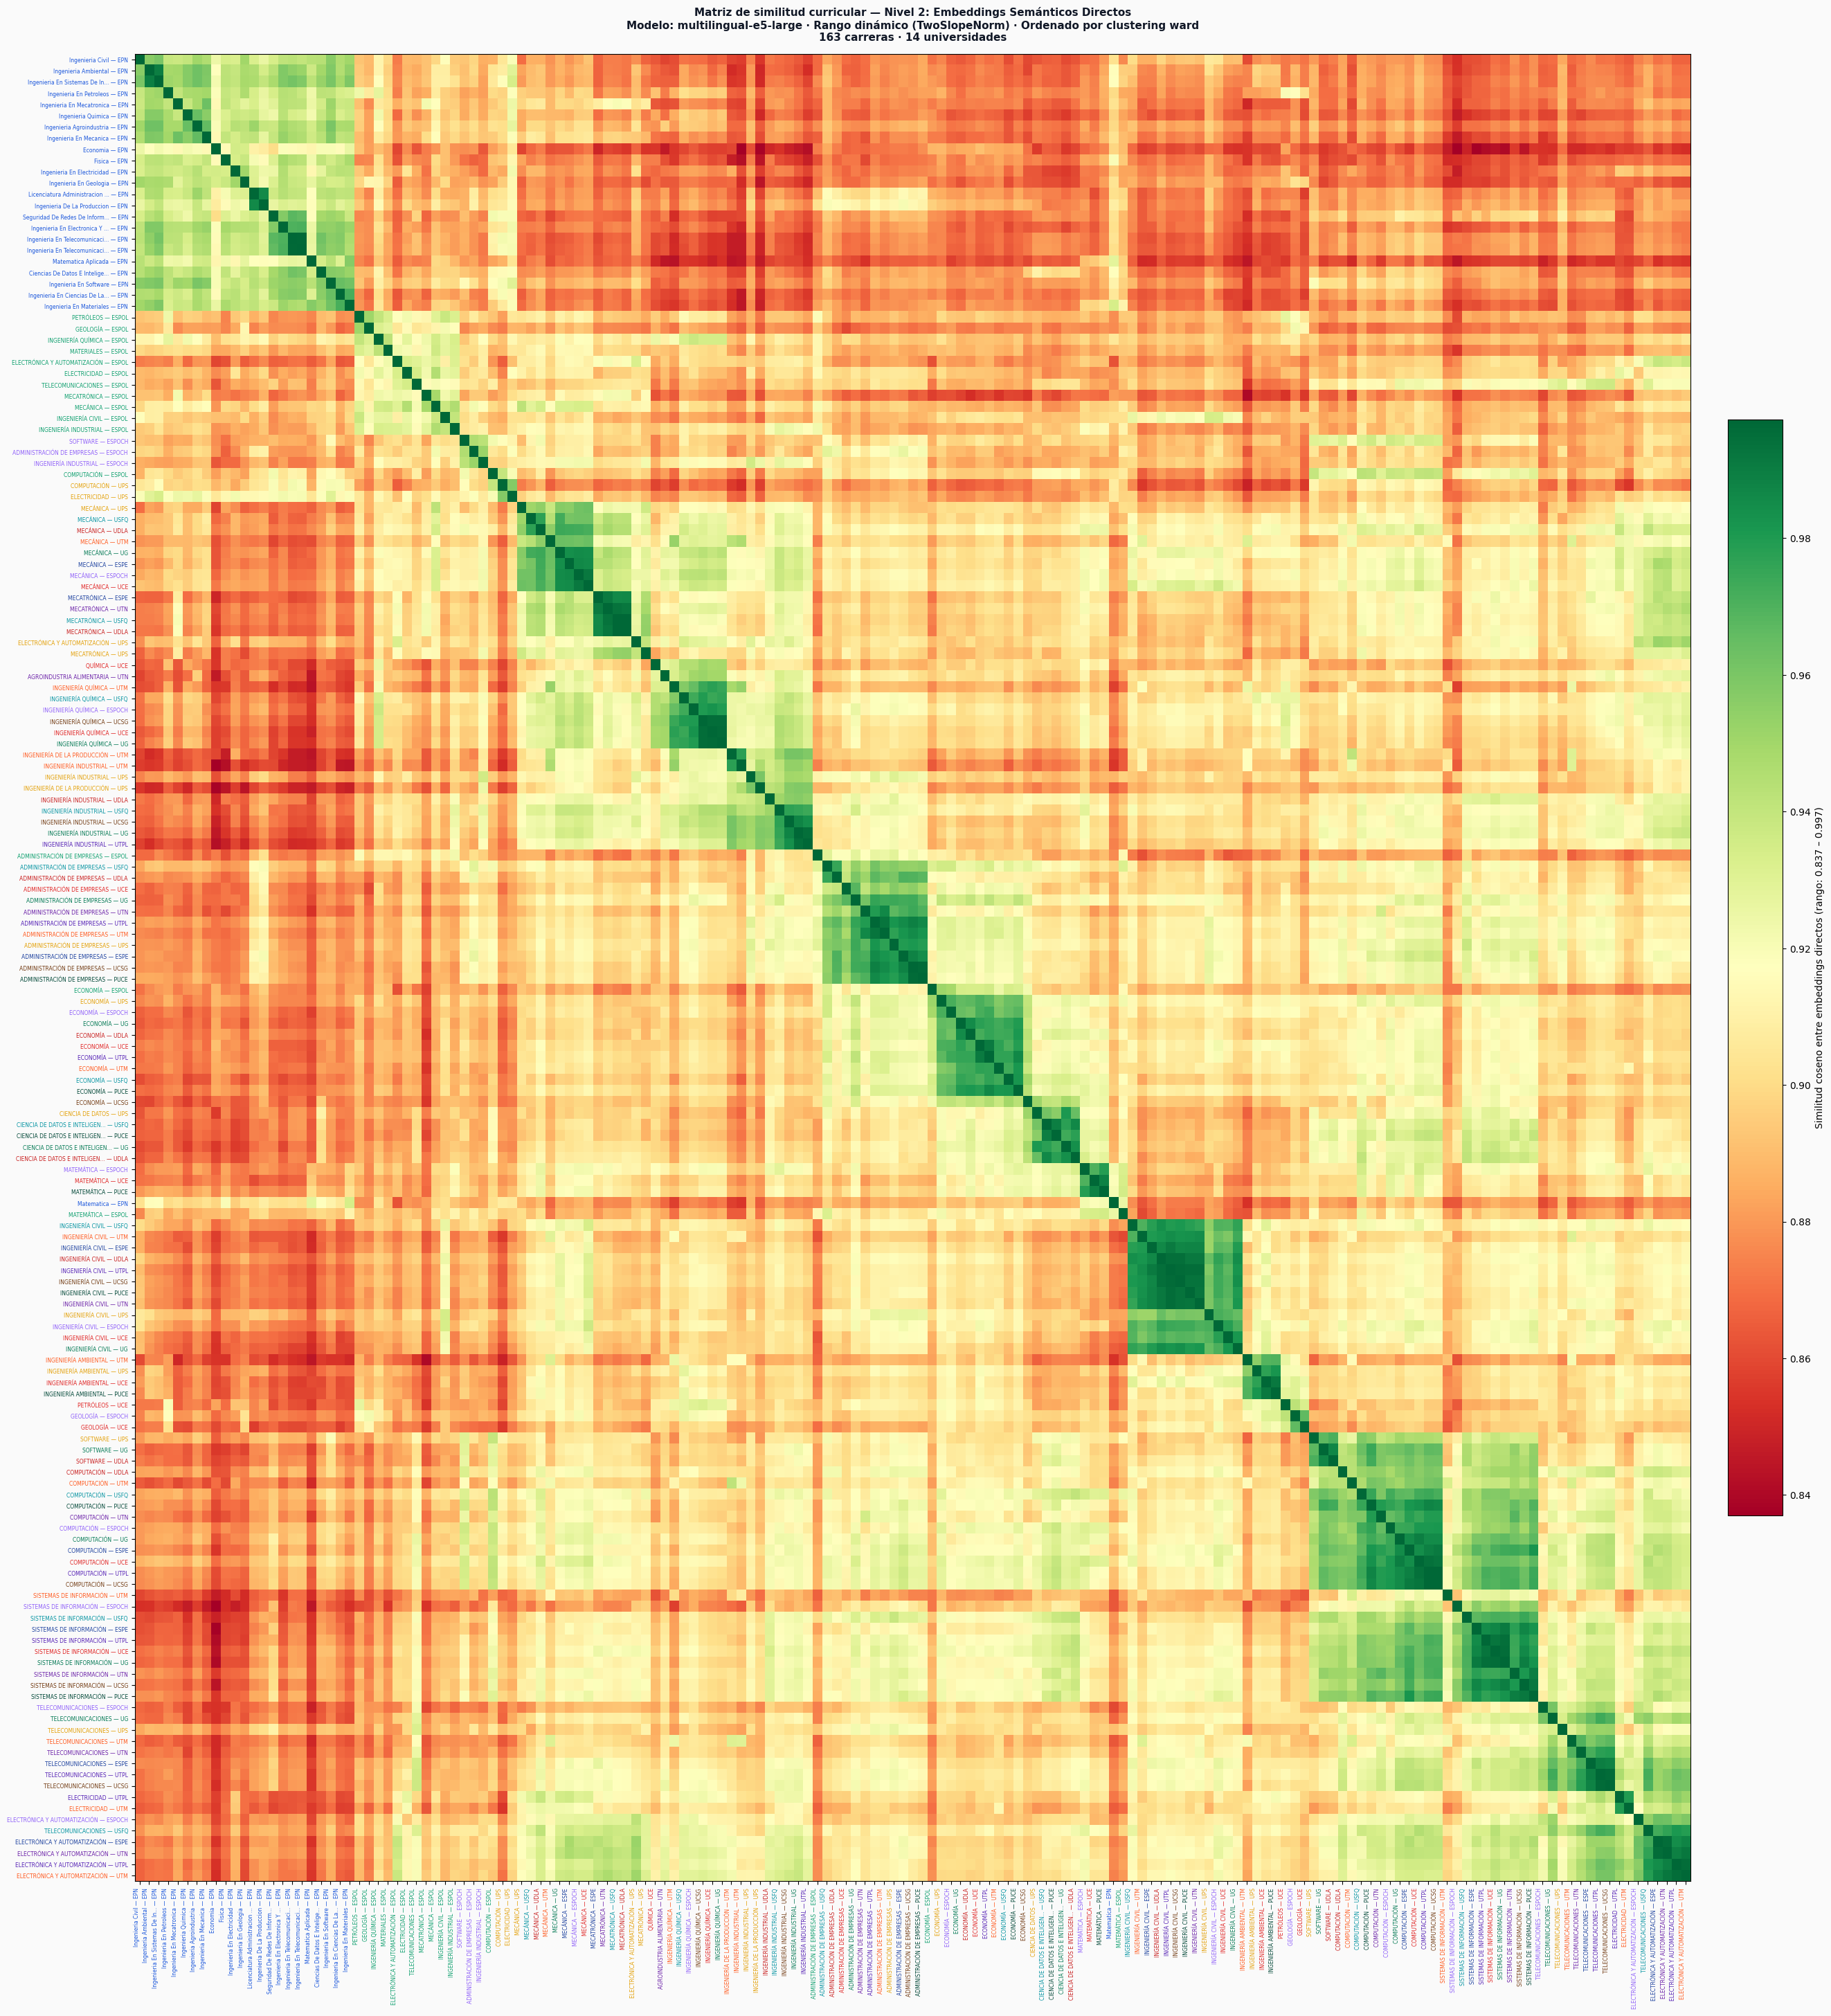


✓ PNG: ..\outputs\2026-07-03\nivel2\heatmap_nivel2_multilingual-e5-large_2026-07-03.png
✓ PDF: ..\outputs\2026-07-03\nivel2\heatmap_nivel2_multilingual-e5-large_2026-07-03.pdf


In [14]:
# ── PARÁMETRO CONFIGURABLE ────────────────────────────────────────────────────
DPI = 150
# ─────────────────────────────────────────────────────────────────────────────

# --- Reordenar según clustering ---
# leaves_list retorna el índice de cada carrera en el orden del dendrograma
orden         = leaves_list(Z)
sim_ordenada  = sim_cc[np.ix_(orden, orden)]

# Etiquetas cortas ordenadas según el dendrograma
etiquetas_h = [
    f"{df_carreras['nombre'].iloc[i][:28]}"
    f"{'...' if len(df_carreras['nombre'].iloc[i]) > 28 else ''}"
    f" — {df_carreras['siglas'].iloc[i]}"
    for i in orden
]

# --- Rango dinámico para el colormap ---
# Excluir la diagonal (siempre = 1.0) para calcular el rango real
mask_d   = ~np.eye(sim_ordenada.shape[0], dtype=bool)
vmin_r   = sim_ordenada[mask_d].min()
vmax_r   = sim_ordenada[mask_d].max()
vcenter  = (vmin_r + vmax_r) / 2

print(f'Rango de similitud semántica directa (sin diagonal):')
print(f'  Mínimo:  {vmin_r:.4f}  ← par de carreras más distinto semánticamente')
print(f'  Máximo:  {vmax_r:.4f}  ← par más similar (sin ser la misma carrera)')
print(f'  Centro:  {vcenter:.4f}  ← punto medio donde el colormap es amarillo')
print(f'  Rango:   {vmax_r - vmin_r:.4f}  ← amplitud total de las diferencias')

# TwoSlopeNorm centra el colormap en el punto medio real, no en 0.5
norm = TwoSlopeNorm(vmin=vmin_r, vcenter=vcenter, vmax=vmax_r)

# --- Figura ---
n        = len(df_carreras)
fig_size = max(20, n * 0.18)
fig, ax  = plt.subplots(figsize=(fig_size, fig_size))
fig.patch.set_facecolor('#fafafa')

im = ax.imshow(
    sim_ordenada,
    cmap='RdYlGn',
    norm=norm,
    aspect='auto',
    interpolation='nearest',
)

plt.colorbar(
    im, ax=ax,
    label=f'Similitud coseno entre embeddings directos (rango: {vmin_r:.3f} – {vmax_r:.3f})',
    shrink=0.6, pad=0.02
)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(etiquetas_h, rotation=90, fontsize=5.5, ha='right')
ax.set_yticklabels(etiquetas_h, fontsize=5.5)

# Colorear etiquetas por universidad
for i, tick in enumerate(ax.get_yticklabels()):
    tick.set_color(get_color(df_carreras['siglas'].iloc[orden[i]]))
for i, tick in enumerate(ax.get_xticklabels()):
    tick.set_color(get_color(df_carreras['siglas'].iloc[orden[i]]))

ax.set_title(
    f'Matriz de similitud curricular — Nivel 2: Embeddings Semánticos Directos\n'
    f'Modelo: {MODELO_SHORT} · Rango dinámico (TwoSlopeNorm) · Ordenado por clustering {METODO}\n'
    f'{n} carreras · {df_carreras["siglas"].nunique()} universidades',
    fontsize=11, fontweight='bold', color='#111827', pad=14,
)
plt.tight_layout(pad=1.5)

base     = f'heatmap_nivel2_{MODELO_SHORT}_{date.today().isoformat()}'
png_path = OUTPUT_DIR / f'{base}.png'
pdf_path = OUTPUT_DIR / f'{base}.pdf'
fig.savefig(png_path, dpi=DPI, bbox_inches='tight', facecolor='#fafafa')
fig.savefig(pdf_path, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'\n✓ PNG: {png_path}')
print(f'✓ PDF: {pdf_path}')

---
## Sección 4 — Métricas de Evaluación

**Qué hace esta celda:**  
Calcula las mismas tres métricas usadas en el Nivel 3 para que los resultados sean comparables entre niveles.

### Las tres métricas

**Cophenetic Correlation**  
Mide qué tan fielmente el dendrograma preserva las distancias originales entre embeddings. Si dos carreras estaban a distancia 0.15 en el espacio de embeddings, ¿se fusionan a altura ~0.15 en el árbol?  
Rango [0,1] — más alto es mejor. Valores > 0.7 son considerados buenos.

**Silhouette Score**  
Para cada carrera calcula: ¿qué tan parecida es a las demás de su cluster vs a las del cluster vecino más cercano?  
Usamos `metric='precomputed'` porque ya tenemos la matriz de distancias `dist_cc` calculada.  
Rango [-1,1] — más alto es mejor. Valores > 0.5 indican clusters bien definidos.

**Pureza de clusters**  
Con k=10 clusters: qué porcentaje de carreras en cada cluster comparte el nombre más frecuente.  
Métrica estricta — subestima la calidad real porque no reconoce sinónimos de nombres de carrera.

### Nota sobre comparabilidad

Estas métricas son directamente comparables con las del Nivel 3 (calculadas en `esco_analysis.ipynb`) porque usan exactamente el mismo método de clustering (Ward), el mismo k para Silhouette y Pureza, y la misma fórmula. La Sección 6 hace esa comparación explícita.

In [15]:
print(f'Métricas de evaluación — Nivel 2 | Modelo: {MODELO_SHORT} | Método: {METODO}')
print('=' * 65)

# ── 1. Cophenetic Correlation ──────────────────────────────────────────────────
cophenetic_corr, _ = cophenet(Z, dist_condensed)
interp_coph = (
    'Excelente (>0.8)'    if cophenetic_corr > 0.8 else
    'Bueno (0.7-0.8)'     if cophenetic_corr > 0.7 else
    'Aceptable (0.6-0.7)' if cophenetic_corr > 0.6 else
    'Débil (<0.6)'
)
print(f'\n1. Cophenetic Correlation')
print(f'   Valor:          {cophenetic_corr:.4f}')
print(f'   Interpretación: {interp_coph}')
print(f'   Significado:    el dendrograma preserva el {cophenetic_corr*100:.1f}%')
print(f'                   de la estructura de distancias entre embeddings')

# ── 2. Silhouette Score ────────────────────────────────────────────────────────
print(f'\n2. Silhouette Score (metric=precomputed sobre dist_cc)')
sil_scores = {}
for k in [5, 7, 10, 15]:
    labels   = fcluster(Z, k, criterion='maxclust')
    score    = silhouette_score(dist_cc, labels, metric='precomputed')
    sil_scores[k] = score
    interp   = (
        'Clusters bien definidos' if score > 0.5  else
        'Estructura moderada'     if score > 0.25 else
        'Sin estructura clara'
    )
    print(f'   k={k:2d}: {score:+.4f}  →  {interp}')

k_opt = max(sil_scores, key=sil_scores.get)
print(f'   Mejor k: {k_opt} (score: {sil_scores[k_opt]:.4f})')

# ── 3. Pureza de clusters ──────────────────────────────────────────────────────
print(f'\n3. Pureza de Clusters (k=10)')
labels_10 = fcluster(Z, 10, criterion='maxclust')
df_ev     = df_carreras[['siglas','nombre']].copy()
df_ev['cluster'] = labels_10
df_ev['nn']      = df_ev['nombre'].str.lower().str.strip()

pureza_clusters = {}
for cid in sorted(df_ev['cluster'].unique()):
    g = df_ev[df_ev['cluster']==cid]
    vc = g['nn'].value_counts()
    p  = vc.iloc[0] / len(g)
    pureza_clusters[cid] = {'n': len(g), 'mayoria': vc.index[0], 'pureza': p}

pureza_prom = sum(v['pureza'] for v in pureza_clusters.values()) / len(pureza_clusters)

for cid, info in pureza_clusters.items():
    barra = '█' * int(info['pureza'] * 20)
    print(f'   Cluster {cid:2d}: {info["pureza"]:.2f} {barra}'
          f'  ({info["n"]} carreras | mayoría: {info["mayoria"][:35]})')

interp_pur = (
    'Alta (>0.8)'     if pureza_prom > 0.8 else
    'Media (0.6-0.8)' if pureza_prom > 0.6 else
    'Baja (<0.6)'
)
print(f'\n   Pureza promedio: {pureza_prom:.4f}  →  {interp_pur}')
print(f'   Nota: métrica estricta — nombres distintos para la misma carrera')
print(f'         cuentan como categorías diferentes')

# ── Guardar métricas ───────────────────────────────────────────────────────────
metricas_n2 = {
    'nivel': 2,
    'modelo': MODELO,
    'metodo': METODO,
    'n_carreras': len(df_carreras),
    'cophenetic': round(float(cophenetic_corr), 4),
    'interpretacion_cophenetic': interp_coph,
    'silhouette': {f'k={k}': round(float(v), 4) for k,v in sil_scores.items()},
    'silhouette_k_optimo': k_opt,
    'pureza_k10': round(float(pureza_prom), 4),
    'interpretacion_pureza': interp_pur,
    'fecha': date.today().isoformat()
}
json_path = OUTPUT_DIR / f'metricas_nivel2_{MODELO_SHORT}_{date.today().isoformat()}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(metricas_n2, f, ensure_ascii=False, indent=2)
print(f'\n✓ Métricas guardadas: {json_path}')

Métricas de evaluación — Nivel 2 | Modelo: multilingual-e5-large | Método: ward

1. Cophenetic Correlation
   Valor:          0.7641
   Interpretación: Bueno (0.7-0.8)
   Significado:    el dendrograma preserva el 76.4%
                   de la estructura de distancias entre embeddings

2. Silhouette Score (metric=precomputed sobre dist_cc)
   k= 5: +0.2328  →  Sin estructura clara
   k= 7: +0.2684  →  Estructura moderada
   k=10: +0.3379  →  Estructura moderada
   k=15: +0.4065  →  Estructura moderada
   Mejor k: 15 (score: 0.4065)

3. Pureza de Clusters (k=10)
   Cluster  1: 0.04   (23 carreras | mayoría: licenciatura administracion de empr)
   Cluster  2: 0.12 ██  (17 carreras | mayoría: computación)
   Cluster  3: 0.57 ███████████  (14 carreras | mayoría: mecánica)
   Cluster  4: 0.41 ████████  (17 carreras | mayoría: ingeniería industrial)
   Cluster  5: 1.00 ████████████████████  (12 carreras | mayoría: administración de empresas)
   Cluster  6: 0.52 ██████████  (21 carreras | ma

---
## Sección 5 — Comparación BGE-M3 vs E5-Large

**Qué hace esta celda:**  
Detecta los embeddings de ambos modelos guardados en `data/processed/` y compara sus métricas lado a lado.

**Cuándo ejecutar:**  
Después de haber ejecutado la Sección 1 con `MODELO = 'BAAI/bge-m3'` y luego de nuevo con `MODELO = 'intfloat/multilingual-e5-large'`. Ambos conjuntos de embeddings quedan guardados en `data/processed/` con sus nombres correspondientes.

**Cómo interpretar la tabla:**  
El fondo verde indica el valor más alto en cada columna. Un modelo que gana en las tres métricas es claramente mejor para este dataset. Si los resultados son mixtos, el análisis visual de los dendrogramas es necesario para complementar la evaluación cuantitativa.

In [16]:
# Detectar embeddings disponibles del Nivel 2
emb_files = sorted(glob.glob(str(PROCESSED / 'embeddings_nivel2_*_*.npy')))

if len(emb_files) < 2:
    print('Solo hay un modelo disponible hasta ahora.')
    print('Ejecuta la Sección 1 con el otro modelo y vuelve aquí.')
    print(f'Archivos encontrados: {[Path(f).name for f in emb_files]}')
else:
    resultados_n2 = []
    modelos_comp  = []

    for emb_file in emb_files:
        # Extraer nombre del modelo del nombre del archivo
        nombre_mod = Path(emb_file).stem.replace('embeddings_nivel2_','').rsplit('_',1)[0]
        modelos_comp.append(nombre_mod)
        print(f'Calculando métricas para: {nombre_mod}...')

        # Cargar embeddings y recalcular matrices
        emb  = np.load(emb_file)
        sc   = cosine_similarity(emb)
        np.fill_diagonal(sc, 1.0)
        dc   = np.clip(1 - sc, 0, None)
        np.fill_diagonal(dc, 0)

        # Clustering
        dc_c = squareform(dc, checks=False)
        Zm   = linkage(dc_c, method=METODO)

        # Métricas
        coph, _ = cophenet(Zm, dc_c)
        sil = {}
        for k in [5, 7, 10, 15]:
            lbl    = fcluster(Zm, k, criterion='maxclust')
            sil[k] = round(float(silhouette_score(dc, lbl, metric='precomputed')), 4)

        lbl10 = fcluster(Zm, 10, criterion='maxclust')
        df_e  = df_carreras[['nombre']].copy()
        df_e['cluster'] = lbl10
        df_e['nn']      = df_e['nombre'].str.lower().str.strip()
        pt = sum(
            df_e[df_e['cluster']==c]['nn'].value_counts().iloc[0] / len(df_e[df_e['cluster']==c])
            for c in df_e['cluster'].unique()
        ) / df_e['cluster'].nunique()

        resultados_n2.append({
            'Modelo':          nombre_mod,
            'Cophenetic':      round(float(coph), 4),
            'Silhouette k=5':  sil[5],
            'Silhouette k=7':  sil[7],
            'Silhouette k=10': sil[10],
            'Silhouette k=15': sil[15],
            'Pureza k=10':     round(float(pt), 4),
        })
        print(f'  ✓ Cophenetic: {coph:.4f} | Silhouette k=10: {sil[10]:+.4f} | Pureza: {pt:.4f}')

    # Tabla comparativa
    df_comp_n2 = pd.DataFrame(resultados_n2).set_index('Modelo')
    print('\n=== COMPARACIÓN BGE-M3 vs E5 — Nivel 2 ===')
    display(
        df_comp_n2.style
        .background_gradient(
            subset=['Cophenetic','Silhouette k=10','Pureza k=10'],
            cmap='RdYlGn'
        )
        .format(precision=4)
        .set_caption(f'Nivel 2: Embeddings directos | Método: {METODO} | {len(df_carreras)} carreras')
    )

    # Guardar
    json_path = OUTPUT_DIR / f'comparacion_nivel2_{date.today().isoformat()}.json'
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(resultados_n2, f, ensure_ascii=False, indent=2)
    print(f'\n✓ Comparación guardada: {json_path}')

Calculando métricas para: bge-m3...
  ✓ Cophenetic: 0.7303 | Silhouette k=10: +0.3281 | Pureza: 0.5276
Calculando métricas para: multilingual-e5-large...
  ✓ Cophenetic: 0.7641 | Silhouette k=10: +0.3379 | Pureza: 0.5260

=== COMPARACIÓN BGE-M3 vs E5 — Nivel 2 ===


,Cophenetic,Silhouette k=5,Silhouette k=7,Silhouette k=10,Silhouette k=15,Pureza k=10
Modelo,,,,,,
bge-m3,0.7303,0.2279,0.2692,0.3281,0.4047,0.5276
multilingual-e5-large,0.7641,0.2328,0.2684,0.3379,0.4065,0.5260



✓ Comparación guardada: ..\outputs\2026-07-03\nivel2\comparacion_nivel2_2026-07-03.json


---
## Sección 6 — Comparación entre Niveles (TF-IDF vs Embeddings vs ESCO)

**Qué hace esta celda:**  
Construye la tabla comparativa central de la tesis: los tres niveles de representación evaluados con las mismas métricas.

**Cuándo ejecutar:**  
Después de haber ejecutado:
- `analysis/dendrogram.py` (Nivel 1 — TF-IDF)
- Este notebook con ambos modelos (Nivel 2)
- `notebooks/esco_analysis.ipynb` Sección 5 (Nivel 3)

**Por qué esta tabla es el corazón del análisis:**  
Permite responder la pregunta central de la metodología:

> *¿Produce un modelo semántico (Nivel 2 o 3) agrupamientos más coherentes que el baseline léxico (TF-IDF)?*

Si las métricas del Nivel 2 y 3 superan consistentemente las del Nivel 1, hay evidencia cuantitativa de que la representación semántica captura mejor la similitud curricular real.

In [ ]:
# Cargar métricas guardadas de cada nivel
# Nivel 1 (TF-IDF) — no tiene JSON de métricas aún, lo calculamos aquí
# Nivel 2 — cargamos desde JSON si existe, sino calculamos
# Nivel 3 — cargamos desde JSON generado por esco_analysis.ipynb

print('Construyendo tabla comparativa entre niveles...')
print()

tabla_niveles = []

# ── Nivel 1: TF-IDF ────────────────────────────────────────────────────────────
print('Calculando métricas para Nivel 1 (TF-IDF)...')
from sklearn.feature_extraction.text import TfidfVectorizer

STOPWORDS_ES = [
    'de','la','el','en','y','a','los','las','que','se','del','un','una',
    'con','por','para','su','sus','es','son','al','lo','como','más','o',
    'pero','si','le','han','hay','ser','estar','tiene','pueden','así',
    'este','esta','entre','también','todo','todos','sobre','cada','sin',
    'no','ni','me','te','nos','les','muy','bien','otro','misma','mismos',
]

corpus_tfidf = (
    df_carreras['perfil_egreso'].fillna('') + ' ' +
    df_carreras['perfil_profesional'].fillna('')
).tolist()

vectorizer = TfidfVectorizer(
    max_features=3000, stop_words=STOPWORDS_ES,
    ngram_range=(1,2), min_df=2, sublinear_tf=True
)
tfidf_mat = vectorizer.fit_transform(corpus_tfidf)
sim_tfidf = cosine_similarity(tfidf_mat)
np.fill_diagonal(sim_tfidf, 1.0)
dist_tfidf = np.clip(1 - sim_tfidf, 0, None)
np.fill_diagonal(dist_tfidf, 0)

dc_t = squareform(dist_tfidf, checks=False)
Z_t  = linkage(dc_t, method=METODO)
coph_t, _ = cophenet(Z_t, dc_t)
sil_t  = silhouette_score(dist_tfidf, fcluster(Z_t,10,'maxclust'), metric='precomputed')
df_et  = df_carreras[['nombre']].copy()
df_et['cluster'] = fcluster(Z_t, 10, 'maxclust')
df_et['nn']      = df_et['nombre'].str.lower().str.strip()
pt_t = sum(
    df_et[df_et['cluster']==c]['nn'].value_counts().iloc[0]/len(df_et[df_et['cluster']==c])
    for c in df_et['cluster'].unique()
) / df_et['cluster'].nunique()

tabla_niveles.append({
    'Nivel': '1 — TF-IDF',
    'Modelo/Método': 'TF-IDF (3000 features, bigramas)',
    'Representación': 'Frecuencia de palabras',
    'Cophenetic': round(float(coph_t), 4),
    'Silhouette k=10': round(float(sil_t), 4),
    'Pureza k=10': round(float(pt_t), 4),
})
print(f'  ✓ TF-IDF: Cophenetic={coph_t:.4f} | Silhouette={sil_t:.4f} | Pureza={pt_t:.4f}')

# ── Nivel 2: Embeddings directos ──────────────────────────────────────────────
emb_files_n2 = sorted(glob.glob(str(PROCESSED / 'embeddings_nivel2_*_*.npy')))
for ef in emb_files_n2:
    nom = Path(ef).stem.replace('embeddings_nivel2_','').rsplit('_',1)[0]
    print(f'Calculando Nivel 2 ({nom})...')
    emb  = np.load(ef)
    sc   = cosine_similarity(emb)
    np.fill_diagonal(sc, 1.0)
    dc   = np.clip(1-sc, 0, None)
    np.fill_diagonal(dc, 0)
    dc_c = squareform(dc, checks=False)
    Zm   = linkage(dc_c, method=METODO)
    coph_m, _ = cophenet(Zm, dc_c)
    sil_m  = silhouette_score(dc, fcluster(Zm,10,'maxclust'), metric='precomputed')
    df_em  = df_carreras[['nombre']].copy()
    df_em['cluster'] = fcluster(Zm, 10, 'maxclust')
    df_em['nn']      = df_em['nombre'].str.lower().str.strip()
    pt_m = sum(
        df_em[df_em['cluster']==c]['nn'].value_counts().iloc[0]/len(df_em[df_em['cluster']==c])
        for c in df_em['cluster'].unique()
    ) / df_em['cluster'].nunique()
    tabla_niveles.append({
        'Nivel': '2 — Embeddings directos',
        'Modelo/Método': nom,
        'Representación': 'Vector semántico (1024 dims)',
        'Cophenetic': round(float(coph_m), 4),
        'Silhouette k=10': round(float(sil_m), 4),
        'Pureza k=10': round(float(pt_m), 4),
    })
    print(f'  ✓ {nom}: Cophenetic={coph_m:.4f} | Silhouette={sil_m:.4f} | Pureza={pt_m:.4f}')

# ── Nivel 3: Vectores ESCO ────────────────────────────────────────────────────
json_n3_files = sorted(glob.glob(str(OUTPUT_DIR.parent / '*' / 'metricas_*_*.json')))
# También buscar en el output de hoy
json_n3_files += sorted(glob.glob(str(OUTPUT_DIR / 'metricas_*_*.json')))

modelos_n3_vistos = set()
for jf in json_n3_files:
    try:
        with open(jf, encoding='utf-8') as f:
            m = json.load(f)
        # Solo incluir si tiene el campo 'modelo' (son del Nivel 3)
        if 'modelo' in m and m.get('modelo','') not in modelos_n3_vistos:
            modelo_n3 = m['modelo']
            modelos_n3_vistos.add(modelo_n3)
            tabla_niveles.append({
                'Nivel': '3 — Vectores ESCO',
                'Modelo/Método': modelo_n3,
                'Representación': 'Vector habilidades ESCO (4241 dims)',
                'Cophenetic': m.get('cophenetic', 'N/D'),
                'Silhouette k=10': m.get('silhouette', {}).get('k=10', 'N/D'),
                'Pureza k=10': m.get('pureza_k10', 'N/D'),
            })
            print(f'  ✓ Nivel 3 ({modelo_n3}): cargado desde JSON')
    except Exception:
        pass

if not modelos_n3_vistos:
    print('  ⚠ No se encontraron métricas del Nivel 3.')
    print('    Ejecuta primero esco_analysis.ipynb Sección 4 para generarlas.')

# ── Tabla final ────────────────────────────────────────────────────────────────
if tabla_niveles:
    df_tabla = pd.DataFrame(tabla_niveles)
    cols_num = ['Cophenetic','Silhouette k=10','Pureza k=10']
    print('\n=== COMPARACIÓN ENTRE NIVELES ===')
    display(
        df_tabla.style
        .background_gradient(subset=cols_num, cmap='RdYlGn')
        .format({c: '{:.4f}' for c in cols_num if df_tabla[c].dtype == float})
        .set_caption(
            'Comparación TF-IDF vs Embeddings directos vs Vectores ESCO\n'
            f'Método de clustering: {METODO} | Dataset: {len(df_carreras)} carreras ecuatorianas'
        )
    )
    json_path = OUTPUT_DIR / f'comparacion_niveles_{date.today().isoformat()}.json'
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(tabla_niveles, f, ensure_ascii=False, indent=2)
    print(f'\n✓ Tabla guardada: {json_path}')

---
## Sección 7 — Interpretación y Conclusiones

**Qué hace esta celda:**  
Genera el resumen de hallazgos del Nivel 2 y la narrativa comparativa entre los tres niveles.

**Cómo usarlo:**  
El texto generado es un punto de partida. Edítalo con tu propia interpretación y los valores específicos que obtengas al ejecutar el análisis completo.

In [ ]:
print('=' * 70)
print('RESUMEN DE HALLAZGOS — Nivel 2: Embeddings Semánticos Directos')
print('=' * 70)
print(f"""
DATASET
  · {len(df_carreras)} carreras de {df_carreras['siglas'].nunique()} universidades ecuatorianas
  · Texto analizado: perfil_egreso + perfil_profesional por carrera
  · Modelos evaluados: BGE-M3 (BAAI) y multilingual-E5-Large (Microsoft)

QUÉ HACE EL NIVEL 2
  Convierte cada perfil de carrera en un vector de 1024 dimensiones que
  captura el significado semántico global del texto. Dos carreras con
  perfiles equivalentes pero vocabulario distinto obtendrán vectores
  cercanos en ese espacio, lo que TF-IDF no podría detectar.

DIFERENCIA CON EL NIVEL 3 (ESCO)
  · Nivel 2: embedding directo del texto → 1024 dims → comparación directa
  · Nivel 3: embedding → comparación contra 4241 habilidades ESCO → vector
             interpretable → comparación mediada por taxonomía estándar
  El Nivel 3 es más interpretable (cada dimensión tiene nombre) pero
  el Nivel 2 puede capturar matices semánticos que ESCO no cubre.

LIMITACIÓN DE E5-LARGE
  El modelo E5-Large tiene un límite de 512 tokens. Los textos más largos
  del dataset (~{sum(1 for _, r in df_carreras.iterrows() if len((r['perfil_egreso']+r['perfil_profesional']).split()) > 380)} carreras con >380 palabras) son truncados,
  lo que puede afectar la calidad de su representación. BGE-M3 no tiene
  esta limitación (soporta hasta 8192 tokens).

NARRATIVA METODOLÓGICA PARA LA TESIS
  "Se compararon tres representaciones de los perfiles curriculares:
  (1) TF-IDF como baseline léxico, que captura coincidencias de
  vocabulario; (2) embeddings semánticos directos con BGE-M3 y E5,
  que capturan el significado global sin intermediario; y (3) vectores
  de habilidades ESCO, que proyectan los perfiles a un espacio de
  competencias estandarizadas e interpretables. Las métricas de
  evaluación (cophenetic correlation, silhouette score y pureza de
  clusters) permiten comparar cuantitativamente la coherencia de los
  agrupamientos producidos por cada representación."
""")
print('=' * 70)